In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path

df = pd.read_csv("D:\\Business Analyst\\Python\\ml_assesment\\Data\\q2_customers.csv")# loading data

print("Rows:\n", df.head())

X = df.copy()
scaler = StandardScaler()
scalred_data = scaler.fit_transform(X)

Rows:
    age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scalred_data)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elboscaledw Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


# Elbow method plots WCSS  against different k values
# As k value increases wcss decreases and increasing k value beyond 3 leads to less/marginal decrease in wcss, hence ideal  value of k is selected as 3

NameError: name 'scalred_data' is not defined

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("D:\\Business Analyst\\Python\\ml_assesment\\Data\\q2_customers.csv")
X = df.copy()
scaler = StandardScaler()
scalred_data = scaler.fit_transform(X)

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scalred_data)
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]  #cluster column excluded
)
print("Cluster Centroids:\n", centroids)

Cluster Centroids:
          age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scalred_data)

#variance
print("Variance Ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

print("\nPCA Loadings:\n", loadings)

#PC1 captures overall customer value and spending behavior, contrasting high-spending infrequent customers with frequent low spenders.
#PC2 captures customer recency, identifying how recently customers have engaged with the business.

Variance Ratio: [0.83560354 0.05568764]

PCA Loadings:
           age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


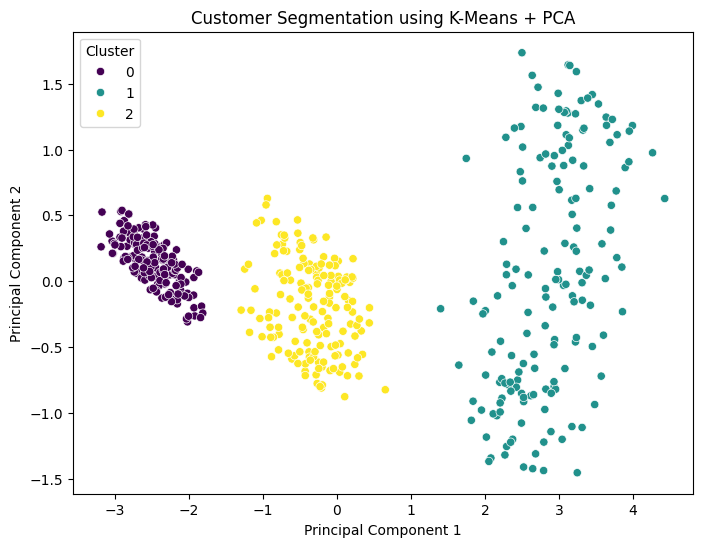

In [12]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['cluster'],
    palette='viridis'
)

plt.title("Customer Segmentation using K-Means + PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()